# MoE Backbone Tests on BDD100K

Testing the new MoE architectures (WP-M0) on actual BDD100K data streams. We will visualize how router probabilities differ between different driving conditions.

In [1]:
import sys
from pathlib import Path

# Add repository root to path
repo_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "cafl4ds/configs").is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Open this notebook from within the cafl4ds repository.")
if str(repo_root) not in sys.path:    sys.path.insert(0, str(repo_root))

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from omegaconf import OmegaConf
from hydra.utils import instantiate
from cafl4ds.models.moe import MoETinyViTEncoder

# BDD100K configuration
IMAGE_SIZE = 64 # Change this variable to control image resolution
PATCH_SIZE = 8 # Match pretrained weights

bdd_root = Path(r"D:\AI Proj\bdd100k_images_100k")
bdd_split = "train"
images_dir = bdd_root / "images" / "100k" / bdd_split
labels_file = bdd_root / "labels" / f"bdd100k_labels_images_{bdd_split}.json"

source_cfg = OmegaConf.create({
    "_target_": "cafl4ds.data.attributes.BDD100KSource",
    "bdd_root": str(bdd_root),
    "split": bdd_split,
    "images_dir": str(images_dir),
    "labels_file": str(labels_file),
    "img_size": IMAGE_SIZE, # small size for quick testing
    "max_images": None, # set to None to use all images
    "min_canary_count": 32,
})

stream_cfg = OmegaConf.create({
    "_target_": "cafl4ds.data.regime.RegimeStream",
    "batch_size": 128,
    "support_per_canary": 8,
    "query_per_canary": 8,
    "era_query_per_cell": 0,
    "max_train_per_regime": None,
    "canary_seed": 0,})

In [3]:
try:
    source = instantiate(source_cfg)
    stream = instantiate(stream_cfg, source=source, seed=13)
    logger.info(f"Loaded {len(stream)} batches.")
except Exception as e:
    logger.warning(f"Could not load BDD100K data (please verify path): {e}")
    stream = None

2026-10-07 08:24:37.019 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['gas stations', 'tunnel']
2026-10-07 08:29:10.485 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 61438 images (train) at 64px over 18 regimes, 4 scenes
2026-10-07 08:29:11.419 | INFO     | __main__:<module>:4 - Loaded 488 batches.


## Visualizing MoE Routing on BDD100K

Here we test the MoE Backbone routing logic on the BDD100K stream. We initialize our `MoETinyViTEncoder` and feed it a batch of images to check which experts process which tokens.

In [4]:
number_of_experts = 4

# --- Change this variable to test different Regimes ---
# e.g. 'daytime', 'night', 'dawn/dusk'
target_regime_names = ['daytime', 'night', 'dawn/dusk']


# Initialize the MoE Encoder
encoder = MoETinyViTEncoder(
    img_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=64, 
    depth=4, num_heads=2, mlp_ratio=2.0, num_experts=number_of_experts, 
    top_k=1, moe_blocks=(2, 3), routing_level='token', 
    balancing_mode='batch'
)

# --- Load pretrained weights and freeze ---
import torch.nn.functional as F

ckpt_path = r'c:\Users\muham\Documents\cafl4ds\outputs\p13-selection-pilot\20260928T200800350523Z\development_well.pt'
ckpt = torch.load(ckpt_path, map_location='cpu')

state_dict = {}
for k, v in ckpt.items():
    if k.startswith('encoder.'):
        state_dict[k.replace('encoder.', '')] = v

# Interpolate pos_embed if grid sizes don't match
pos_embed_ckpt = state_dict['pos_embed']
if pos_embed_ckpt.shape != encoder.pos_embed.shape:
    cls_pos = pos_embed_ckpt[:, :1, :]
    spatial_pos = pos_embed_ckpt[:, 1:, :]
    ckpt_grid = int(spatial_pos.shape[1] ** 0.5)
    spatial_pos = spatial_pos.reshape(1, ckpt_grid, ckpt_grid, -1).permute(0, 3, 1, 2)
    
    curr_grid = int((encoder.pos_embed.shape[1] - 1) ** 0.5)
    spatial_pos_resized = F.interpolate(spatial_pos, size=(curr_grid, curr_grid), mode='bicubic', align_corners=False)
    spatial_pos_resized = spatial_pos_resized.permute(0, 2, 3, 1).reshape(1, curr_grid**2, -1)
    
    state_dict['pos_embed'] = torch.cat([cls_pos, spatial_pos_resized], dim=1)

# Load into encoder
missing, unexpected = encoder.load_state_dict(state_dict, strict=False)
logger.info(f"Loaded pretrained weights. Missing keys (should be MoE blocks): {missing}")

# Freeze non-MoE blocks
for name, param in encoder.named_parameters():
    # Only keep MoE blocks trainable
    if not ('blocks.2.' in name or 'blocks.3.' in name):
        param.requires_grad = False
logger.info("Froze pretrained shared backbone.")
# ----------------------------------------


if stream is not None and len(stream) > 0:
    
    target_era = 0
    if hasattr(stream, 'regime_names') and hasattr(stream, '_regime_order'):
        try:
            # stream.regime_names is a dict[int, str]
            reg_id = next(k for k, v in stream.regime_names.items() if target_regime_names[0] in v)
            target_era = stream._regime_order.index(reg_id)
        except (ValueError, StopIteration):
            logger.warning(f"Regime '{target_regime_names}' not found. Using first batch.")
            
    batch = next((b for b in stream if b.era == target_era), None)
    if batch is None:
        batch = next(iter(stream))
    device = next(encoder.parameters()).device
    imgs = batch.images.to(device)
    logger.info(f"Processing batch for '{target_regime_names}' with {imgs.shape[0]} images.")
else:
    # Fallback to dummy data if dataset is not found
    raise ValueError("Stream failed to load! Please check the BDD100K data path and memory usage.")

# Forward pass to get routing probabilities
embeds = encoder.embed(imgs)
probs = encoder.routing(imgs)
print(f"Auxiliary balancing loss: {encoder.aux_loss:.4f}")

2026-10-07 08:29:11.446 | INFO     | __main__:<module>:43 - Loaded pretrained weights. Missing keys (should be MoE blocks): ['blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.qkv.bias', 'blocks.2.attn.proj.weight', 'blocks.2.attn.proj.bias', 'blocks.2.norm2.weight', 'blocks.2.norm2.bias', 'blocks.2.mlp.ema_expert_load', 'blocks.2.mlp.expert_bias', 'blocks.2.mlp.experts.0.fc1.weight', 'blocks.2.mlp.experts.0.fc1.bias', 'blocks.2.mlp.experts.0.fc2.weight', 'blocks.2.mlp.experts.0.fc2.bias', 'blocks.2.mlp.experts.1.fc1.weight', 'blocks.2.mlp.experts.1.fc1.bias', 'blocks.2.mlp.experts.1.fc2.weight', 'blocks.2.mlp.experts.1.fc2.bias', 'blocks.2.mlp.experts.2.fc1.weight', 'blocks.2.mlp.experts.2.fc1.bias', 'blocks.2.mlp.experts.2.fc2.weight', 'blocks.2.mlp.experts.2.fc2.bias', 'blocks.2.mlp.experts.3.fc1.weight', 'blocks.2.mlp.experts.3.fc1.bias', 'blocks.2.mlp.experts.3.fc2.weight', 'blocks.2.mlp.experts.3.fc2.bias', 'blocks.2.mlp.router.weight', 'bl

Auxiliary balancing loss: 10.9278


### Routing Probabilities Visualization

We visualize the routing probabilities for each MoE block. A heatmap illustrates how tokens (y-axis) are distributed among the 4 experts (x-axis).

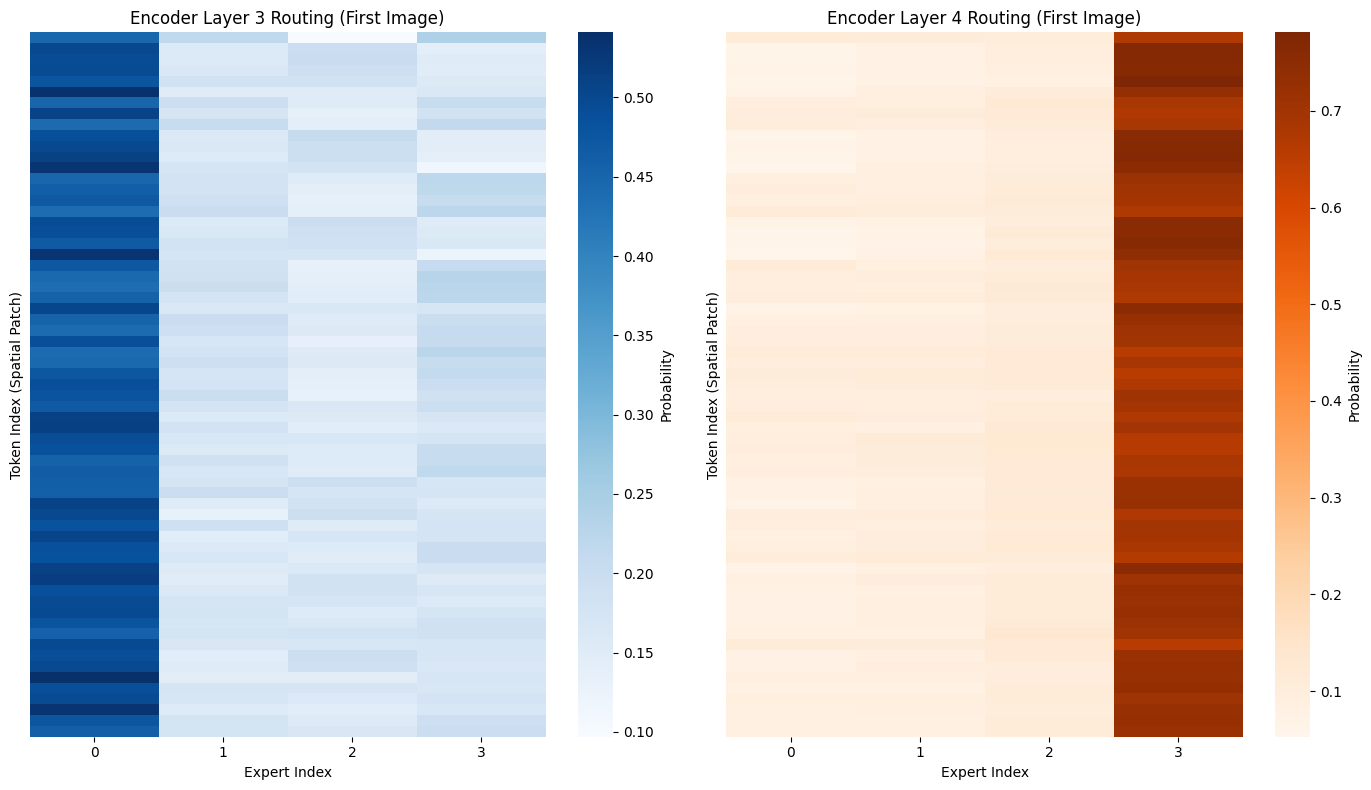

In [5]:
probs_block2 = probs[0].detach().cpu().numpy()  # [B, T, E]
probs_block3 = probs[1].detach().cpu().numpy()  # [B, T, E]

sample_idx = 0 # Visualize the first image in the batch

# Calculate number of tokens and adjust annotations dynamically
num_tokens = probs_block2.shape[1]
show_annot = num_tokens <= 32
yticklabels = [f"{i}" for i in range(num_tokens)] if show_annot else False
fig_height = max(6, int(num_tokens * 0.3)) if show_annot else 8

fig, axes = plt.subplots(1, 2, figsize=(14, fig_height))

sns.heatmap(probs_block2[sample_idx], cmap='Blues', ax=axes[0], cbar_kws={'label': 'Probability'}, annot=show_annot, fmt=".2f", yticklabels=yticklabels)
axes[0].set_title(f'Encoder Layer 3 Routing (First Image)')
axes[0].set_xlabel('Expert Index')
axes[0].set_ylabel('Token Index (Spatial Patch)')

sns.heatmap(probs_block3[sample_idx], cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Probability'}, annot=show_annot, fmt=".2f", yticklabels=yticklabels)
axes[1].set_title(f'Encoder Layer 4 Routing (First Image)')
axes[1].set_xlabel('Expert Index')
axes[1].set_ylabel('Token Index (Spatial Patch)')

plt.tight_layout()
plt.show()

### Spatial Routing Distribution (GradCAM-like)

We project the expert routing probabilities back to the spatial dimensions of the image. This allows us to see which parts of the image each expert specializes in processing.

C:\Users\muham\AppData\Local\Temp\ipykernel_26284\2135633056.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


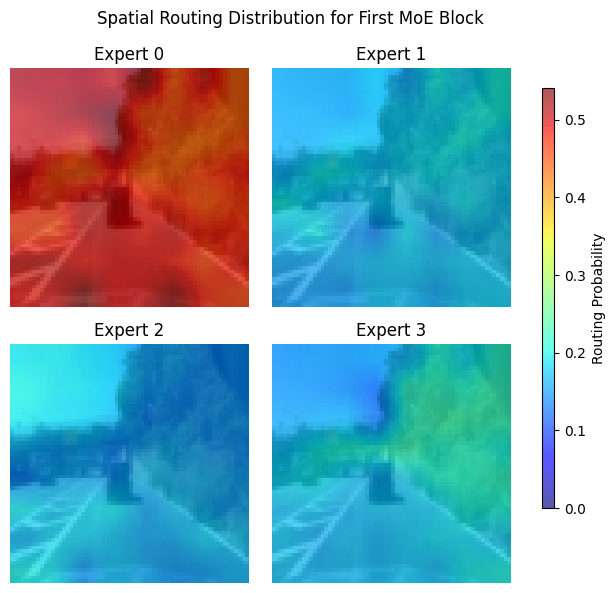

In [6]:
import torch.nn.functional as F
import numpy as np
import math

sample_idx = 0
img = imgs[sample_idx].cpu().detach().cpu().numpy().transpose(1, 2, 0)
# Normalize image for visualization
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

# We visualize the spatial routing for the first MoE block
p_block = probs[0][sample_idx].detach().cpu()  # [T, E]
num_patches = (IMAGE_SIZE // PATCH_SIZE) ** 2
if p_block.shape[0] > num_patches:
    p_block = p_block[-num_patches:]  # Keep only spatial patches if class token is present

E = p_block.shape[1]
grid_size = int(np.sqrt(p_block.shape[0]))
img_size = imgs.shape[2:]

cols = math.ceil(E / 2)
fig, axes = plt.subplots(2, cols, figsize=(3 * cols, 6))
axes = axes.flatten()

vmax_val = p_block.max().item() # Dynamic vmax for stronger heatmap

for e in range(E):
    expert_prob = p_block[:, e].view(1, 1, grid_size, grid_size)
    expert_prob_resized = F.interpolate(expert_prob, size=img_size, mode='bilinear', align_corners=False)
    expert_prob_resized = expert_prob_resized.squeeze().numpy()
    
    ax = axes[e]
    ax.imshow(img)
    im = ax.imshow(expert_prob_resized, cmap='jet', alpha=0.65, vmin=0, vmax=vmax_val)
    ax.set_title(f'Expert {e}')
    ax.axis('off')

# Hide any unused subplots
for e in range(E, len(axes)):
    axes[e].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Routing Probability')
plt.suptitle('Spatial Routing Distribution for First MoE Block')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Mean Expert Usage

Let's look at the overall expert usage across the entire batch.

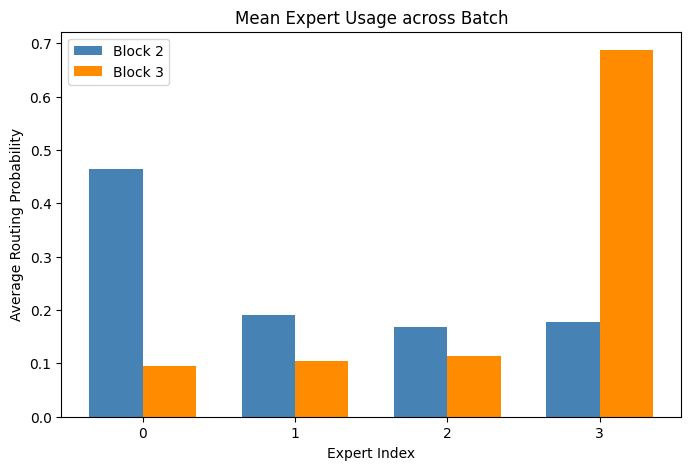

In [7]:
# Compute average expert load across the batch and all tokens
mean_usage_block2 = probs_block2.mean(axis=(0, 1))
mean_usage_block3 = probs_block3.mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
x = range(number_of_experts)

ax.bar([i - width/2 for i in x], mean_usage_block2, width, label='Block 2', color='steelblue')
ax.bar([i + width/2 for i in x], mean_usage_block3, width, label='Block 3', color='darkorange')

ax.set_xlabel('Expert Index')
ax.set_ylabel('Average Routing Probability')
ax.set_title('Mean Expert Usage across Batch')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}' for i in x])
ax.legend()
plt.show()

## Regime Routing Comparison

Here we systematically compare how different regimes (e.g. daytime vs night vs dawn/dusk) influence the expert routing distribution.

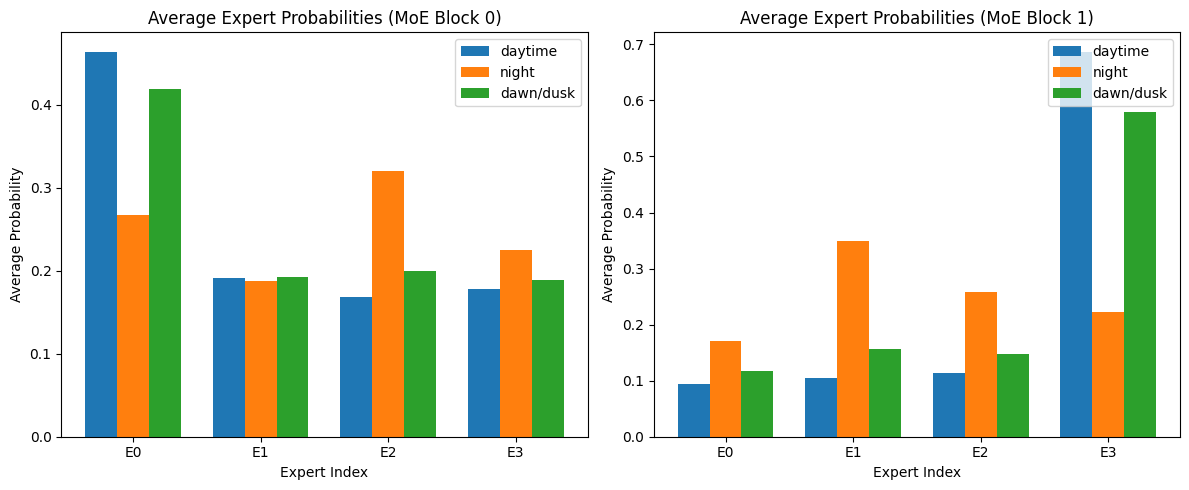

In [8]:
import numpy as np
import matplotlib.pyplot as plt

regimes_to_test = ['daytime', 'night', 'dawn/dusk']
expert_counts_per_regime = {}

if stream is not None:
    for regime_name in regimes_to_test:
        try:
            reg_id = next(k for k, v in stream.regime_names.items() if regime_name in v)
            target_era = stream._regime_order.index(reg_id)
            batch = next((b for b in stream if b.era == target_era), None)
            if batch is not None:
                device = next(encoder.parameters()).device
                imgs = batch.images.to(device)
                with torch.no_grad():
                    probs = encoder.routing(imgs)
                # probs is a list of tensors of shape [batch_size * seq_len, num_experts]
                agg_probs = []
                for prob in probs:
                    avg_prob = prob.mean(dim=(0, 1)).cpu().numpy()
                    agg_probs.append(avg_prob)
                expert_counts_per_regime[regime_name] = agg_probs
        except (ValueError, StopIteration):
            logger.warning(f"Regime containing '{regime_name}' not found in stream.")

if expert_counts_per_regime:
    num_blocks = len(next(iter(expert_counts_per_regime.values())))
    fig, axes = plt.subplots(1, num_blocks, figsize=(6 * num_blocks, 5))
    if num_blocks == 1:
        axes = [axes]
    
    for i in range(num_blocks):
        ax = axes[i]
        num_experts = len(next(iter(expert_counts_per_regime.values()))[i])
        x = np.arange(num_experts)
        width = 0.25
        multiplier = 0
        
        for regime_name, agg_probs in expert_counts_per_regime.items():
            offset = width * multiplier
            rects = ax.bar(x + offset, agg_probs[i], width, label=regime_name)
            multiplier += 1
            
        ax.set_title(f'Average Expert Probabilities (MoE Block {i})')
        ax.set_xlabel('Expert Index')
        ax.set_ylabel('Average Probability')
        ax.set_xticks(x + width * (len(expert_counts_per_regime) - 1) / 2)
        ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()
else:
    print("No valid regimes found for comparison.")


## Training the MoE Encoder via SimSiam

We hook up our `MoETinyViTEncoder` into the `SimSiam` SSL framework and train it for 250 batches. This will allow the router weights to learn from the data, meaning experts will start to specialize semantically. After training, we can re-run the routing comparison to observe meaningful differences!

In [ ]:
from cafl4ds.ssl.factory import build_simsiam
import torch.optim as optim
from tqdm.auto import tqdm

# Build SimSiam wrapping our MoE encoder
simsiam = build_simsiam(encoder)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
simsiam = simsiam.to(device)

simsiam.aux_weight = 1.0

optimizer = optim.AdamW(simsiam.parameters(), lr=1e-5, weight_decay=1e-4)

simsiam.train()
epochs = 20
max_batches_per_epoch = 150
logger.info(f"Starting SimSiam training for {epochs} epochs ({max_batches_per_epoch} batches each) on {device}...")

from cafl4ds.measurements import rankme
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

history = {
    'epoch': [],
    'loss': [],
    'rankme': []
}

if stream is not None:
    train_iterator = iter(stream)
    
    # Filter for the target regimes
    allowed_eras = set()
    if hasattr(stream, 'regime_names') and hasattr(stream, '_regime_order'):
        for t_regime in target_regime_names:
            try:
                reg_id = next(k for k, v in stream.regime_names.items() if t_regime in v)
                allowed_eras.add(stream._regime_order.index(reg_id))
            except (ValueError, StopIteration):
                pass
                
    for epoch in range(epochs):
        epoch_losses = []
        all_embeddings = []
        
        for step in tqdm(range(max_batches_per_epoch), desc=f"Epoch {epoch+1}/{epochs}"):
            try:
                batch = next(train_iterator)
                if allowed_eras:
                    while batch.era not in allowed_eras:
                        batch = next(train_iterator)
            except StopIteration:
                train_iterator = iter(stream)
                batch = next(train_iterator)
                if allowed_eras:
                    while batch.era not in allowed_eras:
                        batch = next(train_iterator)
                
            imgs = batch.images.to(device)
            
            if imgs.shape[0] == 1:
                # logger.warning("Skipping batch of size 1 to prevent BatchNorm error.")
                continue
            
            optimizer.zero_grad()
            # Forward pass through SSL method
            loss = simsiam.training_step(imgs)
            
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            
            # Save some representations for rankme tracking
            if step >= max_batches_per_epoch - 20: # Last 20 batches of epoch
                encoder.eval()
                with torch.no_grad():
                    z = encoder.embed(imgs)
                    all_embeddings.append(z.cpu())
                simsiam.train() # Restore train mode
                    
        Z = torch.cat(all_embeddings, dim=0)
        rm = rankme(Z)
        avg_loss = np.mean(epoch_losses)
        
        history['epoch'].append(epoch + 1)
        history['loss'].append(avg_loss)
        history['rankme'].append(rm)
        logger.info(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | RankMe: {rm:.2f}")

    logger.info("Training complete! Run the next cell to see performance graphs.")
else:
    logger.warning("Stream is None, cannot train.")

c:\Users\muham\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-10-07 08:29:12.499 | INFO     | __main__:<module>:17 - Starting SimSiam training for 20 epochs (150 batches each) on cuda...
Epoch 1/20: 100%|██████████| 150/150 [00:07<00:00, 19.96it/s]
2026-10-07 08:29:20.349 | INFO     | __main__:<module>:89 - Epoch 1 | Loss: 9.4375 | RankMe: 6.48
Epoch 2/20: 100%|██████████| 150/150 [00:07<00:00, 21.28it/s]
2026-10-07 08:29:27.402 | INFO     | __main__:<module>:89 - Epoch 2 | Loss: 5.6395 | RankMe: 7.77
Epoch 3/20: 100%|██████████| 150/150 [00:07<00:00, 21.04it/s]
2026-10-07 08:29:34.534 | INFO     | __main__:<module>:89 - Epoch 3 | Loss: 6.5476 | RankMe: 6.25
Epoch 4/20: 100%|██████████| 150/150 [00:07<00:00, 21.07it/s]
2026-10-07 08:29:41.656 | INFO     | __main__:<mod

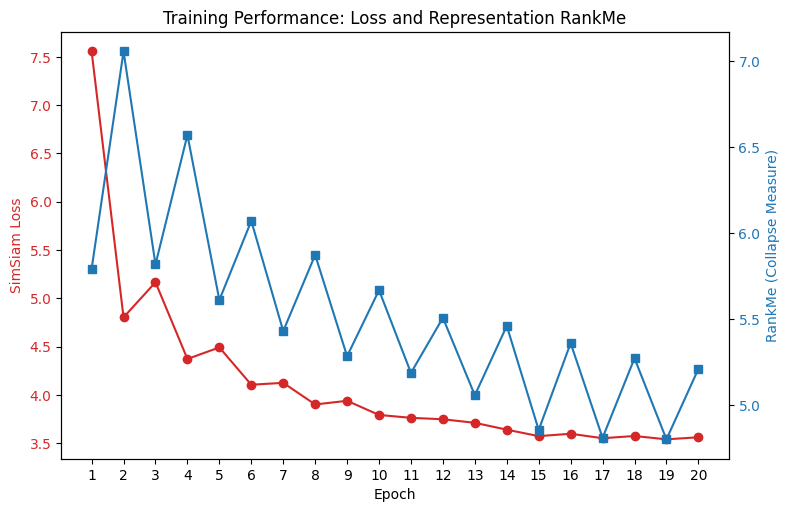

In [ ]:
# Plot training performance over epochs
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('SimSiam Loss', color=color)
ax1.plot(history['epoch'], history['loss'], color=color, marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(history['epoch'])

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('RankMe (Collapse Measure)', color=color)  
ax2.plot(history['epoch'], history['rankme'], color=color, marker='s', label='RankMe')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('Training Performance: Loss and Representation RankMe')
plt.show()


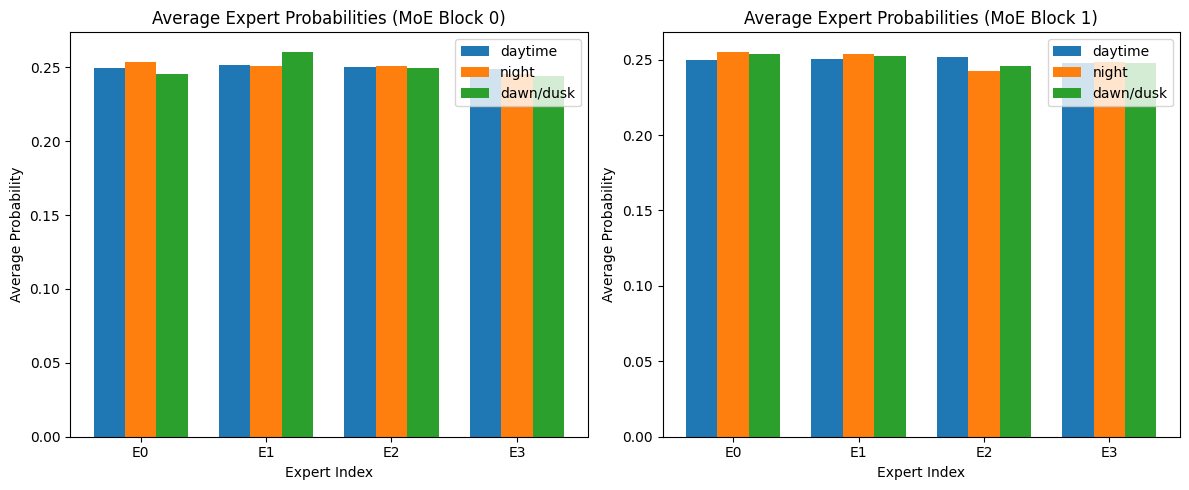

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

regimes_to_test = ['daytime', 'night', 'dawn/dusk']
expert_counts_per_regime = {}

if stream is not None:
    for regime_name in regimes_to_test:
        try:
            reg_id = next(k for k, v in stream.regime_names.items() if regime_name in v)
            target_era = stream._regime_order.index(reg_id)
            batch = next((b for b in stream if b.era == target_era), None)
            if batch is not None:
                device = next(encoder.parameters()).device
                imgs = batch.images.to(device)
                with torch.no_grad():
                    probs = encoder.routing(imgs)
                # probs is a list of tensors of shape [batch_size * seq_len, num_experts]
                agg_probs = []
                for prob in probs:
                    avg_prob = prob.mean(dim=(0, 1)).cpu().numpy()
                    agg_probs.append(avg_prob)
                expert_counts_per_regime[regime_name] = agg_probs
        except (ValueError, StopIteration):
            logger.warning(f"Regime containing '{regime_name}' not found in stream.")

if expert_counts_per_regime:
    num_blocks = len(next(iter(expert_counts_per_regime.values())))
    fig, axes = plt.subplots(1, num_blocks, figsize=(6 * num_blocks, 5))
    if num_blocks == 1:
        axes = [axes]
    
    for i in range(num_blocks):
        ax = axes[i]
        num_experts = len(next(iter(expert_counts_per_regime.values()))[i])
        x = np.arange(num_experts)
        width = 0.25
        multiplier = 0
        
        for regime_name, agg_probs in expert_counts_per_regime.items():
            offset = width * multiplier
            rects = ax.bar(x + offset, agg_probs[i], width, label=regime_name)
            multiplier += 1
            
        ax.set_title(f'Average Expert Probabilities (MoE Block {i})')
        ax.set_xlabel('Expert Index')
        ax.set_ylabel('Average Probability')
        ax.set_xticks(x + width * (len(expert_counts_per_regime) - 1) / 2)
        ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()
else:    print("No valid regimes found for comparison.")

### Routing Probabilities Visualization

We visualize the routing probabilities for each MoE block. A heatmap illustrates how tokens (y-axis) are distributed among the 4 experts (x-axis).

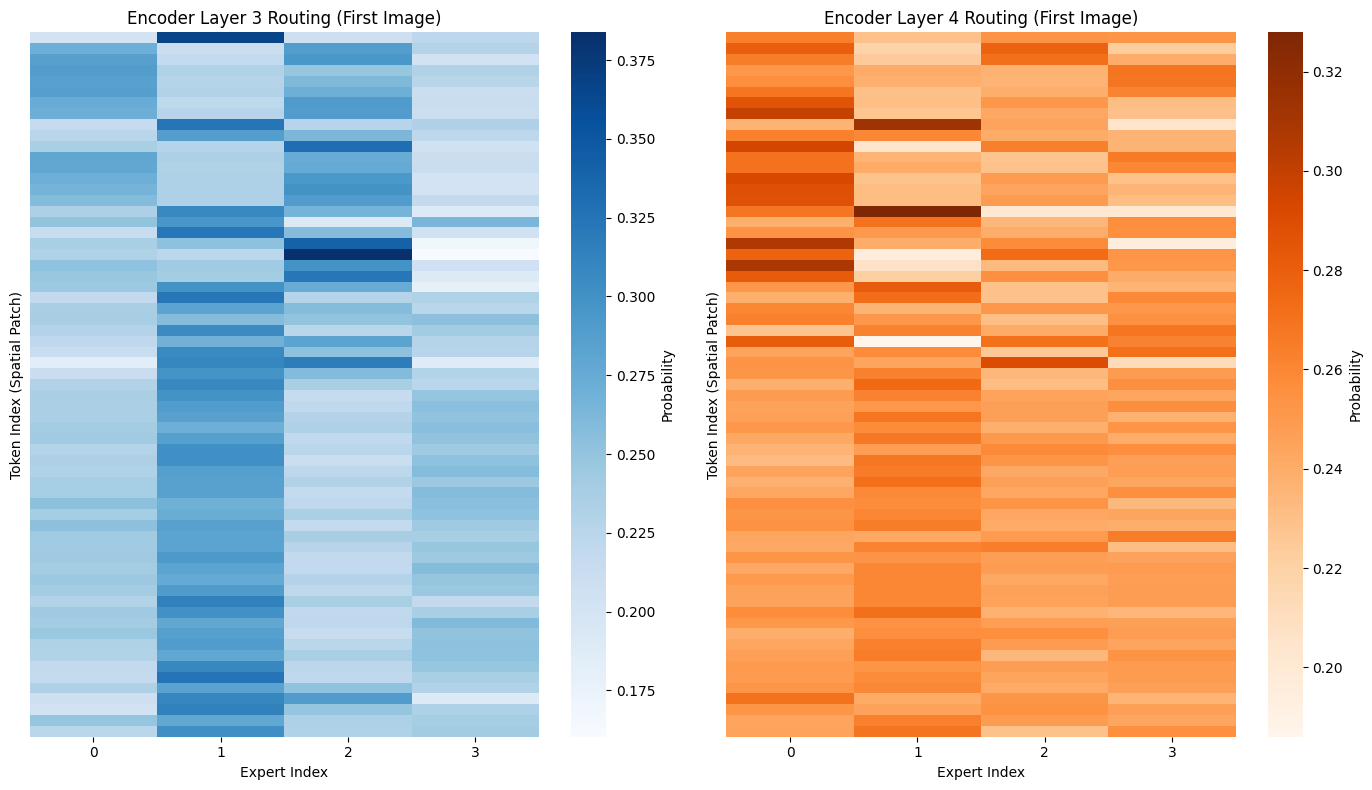

In [ ]:
probs_block2 = probs[0].detach().cpu().numpy()  # [B, T, E]
probs_block3 = probs[1].detach().cpu().numpy()  # [B, T, E]

sample_idx = 0 # Visualize the first image in the batch

# Calculate number of tokens and adjust annotations dynamically
num_tokens = probs_block2.shape[1]
show_annot = num_tokens <= 32
yticklabels = [f"{i}" for i in range(num_tokens)] if show_annot else False
fig_height = max(6, int(num_tokens * 0.3)) if show_annot else 8

fig, axes = plt.subplots(1, 2, figsize=(14, fig_height))

sns.heatmap(probs_block2[sample_idx], cmap='Blues', ax=axes[0], cbar_kws={'label': 'Probability'}, annot=show_annot, fmt=".2f", yticklabels=yticklabels)
axes[0].set_title(f'Encoder Layer 3 Routing (First Image)')
axes[0].set_xlabel('Expert Index')
axes[0].set_ylabel('Token Index (Spatial Patch)')

sns.heatmap(probs_block3[sample_idx], cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Probability'}, annot=show_annot, fmt=".2f", yticklabels=yticklabels)
axes[1].set_title(f'Encoder Layer 4 Routing (First Image)')
axes[1].set_xlabel('Expert Index')
axes[1].set_ylabel('Token Index (Spatial Patch)')

plt.tight_layout()
plt.show()

### Spatial Routing Distribution

We project the expert routing probabilities back to the spatial dimensions of the image. This allows us to see which parts of the image each expert specializes in processing.

C:\Users\muham\AppData\Local\Temp\ipykernel_38324\3084769648.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


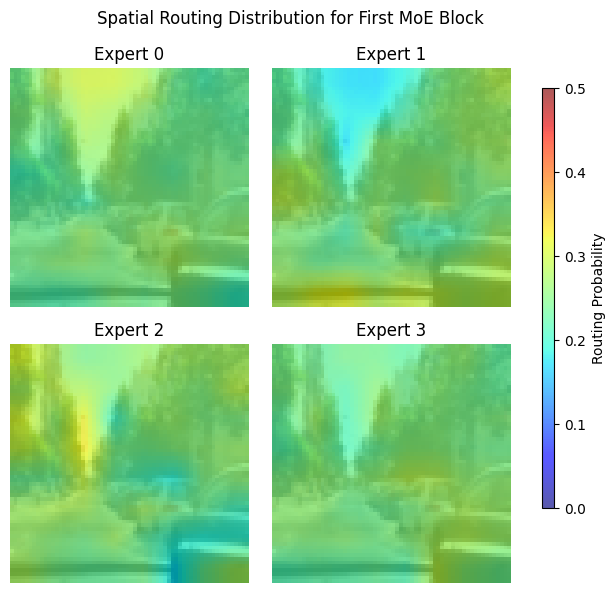

In [ ]:
import torch.nn.functional as F
import numpy as np
import math

sample_idx = 3
img = imgs[sample_idx].cpu().detach().cpu().numpy().transpose(1, 2, 0)
# Normalize image for visualization
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

# We visualize the spatial routing for the first MoE block
p_block = probs[0][sample_idx].detach().cpu()  # [T, E]
num_patches = (IMAGE_SIZE // PATCH_SIZE) ** 2
if p_block.shape[0] > num_patches:
    p_block = p_block[-num_patches:]  # Keep only spatial patches if class token is present

E = p_block.shape[1]
grid_size = int(np.sqrt(p_block.shape[0]))
img_size = imgs.shape[2:]

cols = math.ceil(E / 2)
fig, axes = plt.subplots(2, cols, figsize=(3 * cols, 6))
axes = axes.flatten()

# vmax_val = p_block.max().item() # Dynamic vmax for stronger heatmap
vmax_val = 0.5 # Fixed vmax for consistent color scaling across experts

for e in range(E):
    expert_prob = p_block[:, e].view(1, 1, grid_size, grid_size)
    expert_prob_resized = F.interpolate(expert_prob, size=img_size, mode='bilinear', align_corners=False)
    expert_prob_resized = expert_prob_resized.squeeze().numpy()
    
    ax = axes[e]
    ax.imshow(img)
    im = ax.imshow(expert_prob_resized, cmap='jet', alpha=0.65, vmin=0, vmax=vmax_val)
    ax.set_title(f'Expert {e}')
    ax.axis('off')

# Hide any unused subplots
for e in range(E, len(axes)):
    axes[e].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Routing Probability')
plt.suptitle('Spatial Routing Distribution for First MoE Block')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


## Activation Maximization


Optimizing for Expert 0...


Expert 0 Prob: 0.3365: 100%|██████████| 300/300 [00:02<00:00, 149.59it/s]



Optimizing for Expert 1...


Expert 1 Prob: 0.4103: 100%|██████████| 300/300 [00:01<00:00, 162.40it/s]



Optimizing for Expert 2...


Expert 2 Prob: 0.5594: 100%|██████████| 300/300 [00:01<00:00, 165.79it/s]



Optimizing for Expert 3...


Expert 3 Prob: 0.2465: 100%|██████████| 300/300 [00:01<00:00, 163.93it/s]


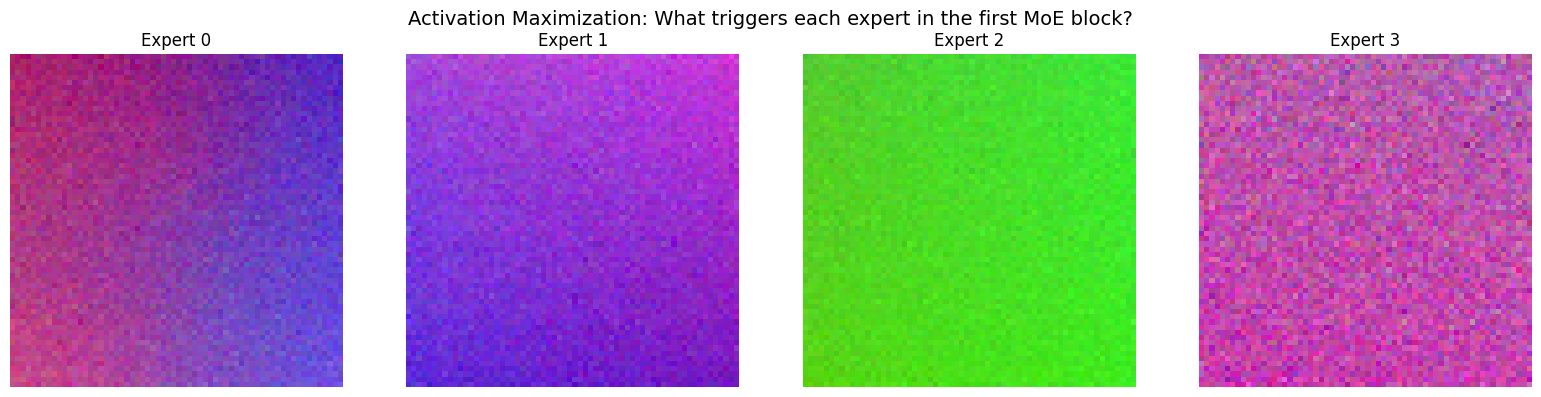

In [ ]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np

def maximize_expert_activation(encoder, target_block_idx=0, target_expert_idx=0, 
                               img_size=64, iterations=300, lr=0.1):
    """
    Optimizes a random image to maximize the routing probability 
    for a specific expert in a specific MoE block.
    """
    device = next(encoder.parameters()).device
    
    # Freeze the encoder completely
    encoder.eval()
    for param in encoder.parameters():
        param.requires_grad = False
        
    # Start with a random noise image
    img = torch.randn(1, 3, img_size, img_size, device=device) * 0.1
    img.requires_grad_(True)
    
    optimizer = Adam([img], lr=lr, weight_decay=1e-4)
    
    pbar = tqdm(range(iterations))
    for i in pbar:
        optimizer.zero_grad()
        
        # Total Variation loss for smoother images
        tv_loss = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:])) + \
                  torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
                  
        # Normal forward pass to maintain the gradient graph
        _ = encoder(img)
        
        # Fetch the router probabilities saved during the forward pass
        actual_block_idx = encoder.moe_blocks[target_block_idx]
        block_probs = encoder.blocks[actual_block_idx].mlp.router_probs
        
        # Maximize the mean probability of tokens being routed to the target expert
        target_prob = block_probs[0, :, target_expert_idx].mean()
        
        # Loss: minimize negative probability + small TV penalty
        loss = -target_prob + 0.01 * tv_loss
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            # Clamp image to prevent exploding values
            img.clamp_(-2.5, 2.5)
            
        if i % 50 == 0:
            pbar.set_description(f"Expert {target_expert_idx} Prob: {target_prob.item():.4f}")
            
    # Format for plotting
    opt_img = img.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    
    # Normalize to [0, 1] for matplotlib display
    opt_img = (opt_img - opt_img.min()) / (opt_img.max() - opt_img.min() + 1e-8)
    
    return opt_img

# --- Run Activation Maximization for the first MoE Block ---
# Get the actual number of experts from the layer
num_experts = encoder.blocks[encoder.moe_blocks[0]].mlp.num_experts

fig, axes = plt.subplots(1, num_experts, figsize=(16, 4))
fig.suptitle("Activation Maximization: What triggers each expert in the first MoE block?", fontsize=14)

for expert_idx in range(num_experts):
    print(f"\nOptimizing for Expert {expert_idx}...")
    img_opt = maximize_expert_activation(encoder, target_block_idx=0, 
                                         target_expert_idx=expert_idx, 
                                         img_size=IMAGE_SIZE)
    axes[expert_idx].imshow(img_opt)
    axes[expert_idx].set_title(f"Expert {expert_idx}")
    axes[expert_idx].axis('off')
    
plt.tight_layout()
plt.show()


## Mutual Information Test

In [ ]:
from sklearn.metrics import mutual_info_score
import numpy as np
from tqdm.auto import tqdm
import torch

def evaluate_routing_mutual_information(encoder, stream, target_block_idx=0, max_batches=None):
    """
    Computes the mutual information between the router's expert assignment 
    and the image's regime (e.g. time of day) to test for specialization.
    """
    device = next(encoder.parameters()).device
    encoder.eval()
    
    y_regime = []
    y_expert = []
    
    print(f"Evaluating mutual information...")
    
    batch_iterator = iter(stream)
    for _ in tqdm(range(max_batches) if max_batches is not None else range(len(stream))):
        try:
            batch = next(batch_iterator)
        except StopIteration:
            break
            
        imgs = batch.images.to(device)
        era = batch.era # The regime index provided by RegimeStream
        
        with torch.no_grad():
            # Standard forward pass
            _ = encoder(imgs)
            
            # Fetch router probabilities
            actual_block_idx = encoder.moe_blocks[target_block_idx]
            block_probs = encoder.blocks[actual_block_idx].mlp.router_probs # Shape: [B, T, E]
            
            # Aggregate token-level routing into an image-level expert assignment
            image_probs = block_probs.mean(dim=1) # Shape: [B, E]
            chosen_experts = image_probs.argmax(dim=-1).cpu().numpy() # Shape: [B]
            
        y_regime.extend([era] * imgs.shape[0])
        y_expert.extend(chosen_experts)
        
    y_regime = np.array(y_regime)
    y_expert = np.array(y_expert)
    
    # 1. Calculate the Observed Mutual Information
    mi = mutual_info_score(y_regime, y_expert)
    
    # 2. Calculate the Label-Permutation Null (Random baseline)
    null_mis = []
    for _ in range(100):
        shuffled_regimes = np.random.permutation(y_regime)
        null_mis.append(mutual_info_score(shuffled_regimes, y_expert))
        
    null_mi_mean = np.mean(null_mis)
    null_mi_std = np.std(null_mis)
    
    # 3. Check for Routing Collapse
    unique_experts, counts = np.unique(y_expert, return_counts=True)
    max_expert_share = np.max(counts) / len(y_expert)
    
    print("\n" + "="*40)
    print("       MUTUAL INFORMATION RESULTS")
    print("="*40)
    print(f"Observed MI:        {mi:.4f} nats")
    print(f"Random Null MI:     {null_mi_mean:.4f} ± {null_mi_std:.4f} nats")
    print("-" * 40)
    
    # Z-score test
    if null_mi_std > 0:
        z_score = (mi - null_mi_mean) / null_mi_std
        print(f"Z-Score: {z_score:.1f}")
        
    if max_expert_share > 0.8:
        print(f"\nWarning: ROUTING COLLAPSE DETECTED!")
        print(f"One expert is processing {max_expert_share*100:.1f}% of all images.")
        print("The high Z-Score is caused by slight distribution shifts in the remaining rare experts, NOT true specialization.")
    elif mi > null_mi_mean + (3 * null_mi_std):
        print("\nConclusion: STRONG EVIDENCE of specialization!")
        print("The router depends heavily on the regime (weather/time of day).")
    else:
        print("\nConclusion: WEAK/NO EVIDENCE of specialization.")
        print("The router assigns experts mostly independently of the regime.")
        
    return mi, y_regime, y_expert

# Run the test on the first MoE block (moe_blocks[0])
mi_score, regimes, experts = evaluate_routing_mutual_information(encoder, stream, target_block_idx=0, max_batches=None)


Evaluating mutual information...


100%|██████████| 488/488 [00:04<00:00, 110.76it/s]



       MUTUAL INFORMATION RESULTS
Observed MI:        0.0765 nats
Random Null MI:     0.0004 ± 0.0001 nats
----------------------------------------
Z-Score: 894.7

Conclusion: STRONG EVIDENCE of specialization!
The router depends heavily on the regime (weather/time of day).


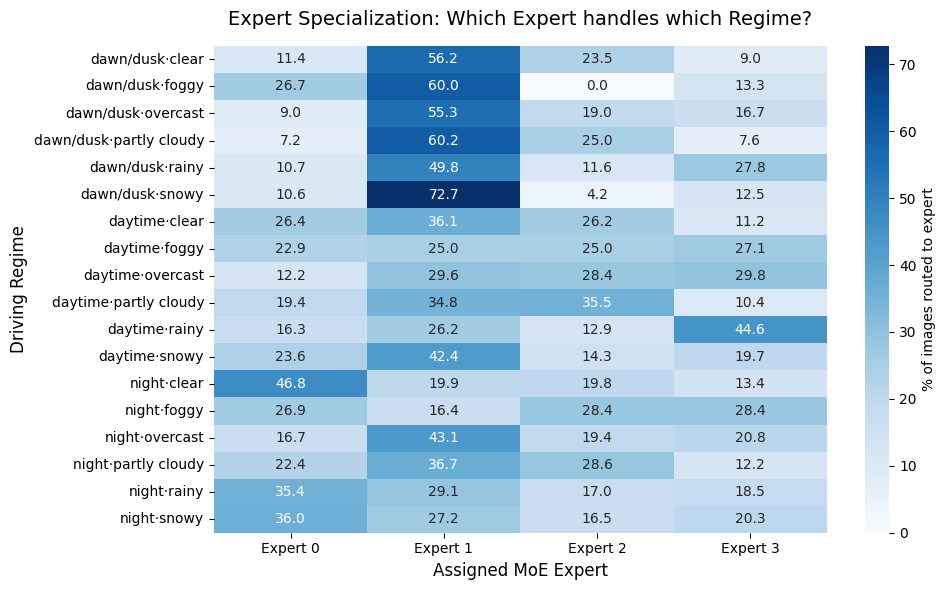

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_regime_expert_heatmap(regimes, experts, stream):
    """
    Visualizes the joint distribution of Regimes and Expert assignments as a heatmap.
    """
    # 1. Map the numerical regime IDs to their actual string names
    regime_names_list = []
    for r in regimes:
        # Fallback to "Regime X" if the name isn't found
        name = stream.regime_names.get(r, f"Regime {r}") if hasattr(stream, 'regime_names') else f"Regime {r}"
        regime_names_list.append(name)
        
    # 2. Create a Pandas DataFrame for easy cross-tabulation
    df = pd.DataFrame({
        'Regime': regime_names_list,
        'Expert': [f"Expert {e}" for e in experts]
    })
    
    # 3. Create a contingency table (counts of how many times each expert was chosen per regime)
    df['Expert'] = pd.Categorical(df['Expert'], categories=[f'Expert {i}' for i in range(4)], ordered=True)
    contingency = pd.crosstab(df['Regime'], df['Expert'], dropna=False)
    
    # 4. Normalize by row (so each regime sums to 100%) to see the distribution clearly
    contingency_norm = contingency.div(contingency.sum(axis=1), axis=0) * 100
    
    # 5. Plot the Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(contingency_norm, annot=True, fmt=".1f", cmap="Blues", 
                cbar_kws={'label': '% of images routed to expert'})
    
    plt.title("Expert Specialization: Which Expert handles which Regime?", pad=15, fontsize=14)
    plt.ylabel("Driving Regime", fontsize=12)
    plt.xlabel("Assigned MoE Expert", fontsize=12)
    
    # Rotate y-labels so they are easy to read
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Run the visualization using the arrays outputted from the MI function
plot_regime_expert_heatmap(regimes, experts, stream)


In [ ]:
mi_score, regimes, experts = evaluate_routing_mutual_information(encoder, stream, target_block_idx=1, max_batches=None)


Evaluating mutual information...


100%|██████████| 488/488 [00:04<00:00, 114.34it/s]



       MUTUAL INFORMATION RESULTS
Observed MI:        0.0496 nats
Random Null MI:     0.0004 ± 0.0001 nats
----------------------------------------
Z-Score: 625.1

Conclusion: STRONG EVIDENCE of specialization!
The router depends heavily on the regime (weather/time of day).


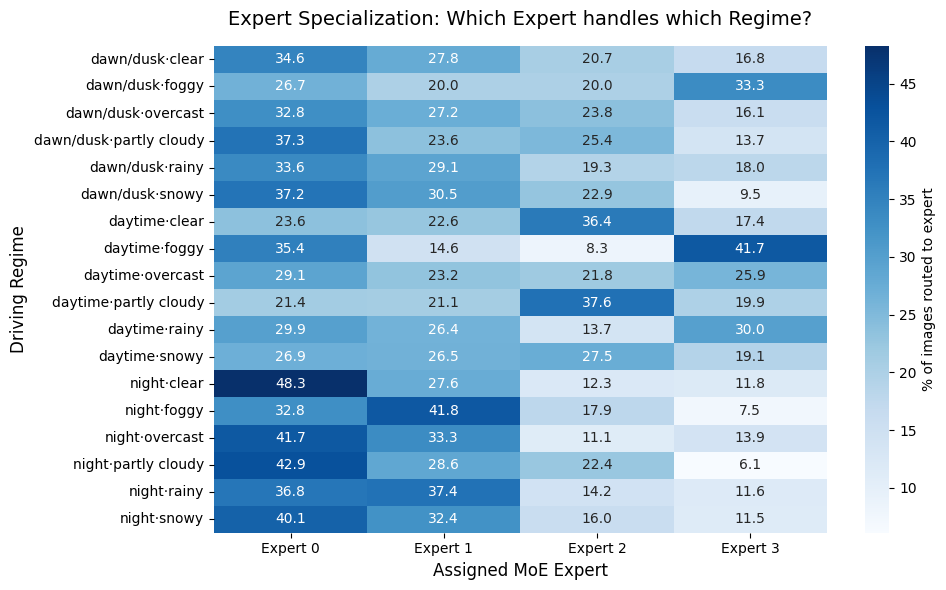

In [ ]:
plot_regime_expert_heatmap(regimes, experts, stream)

## H2 Test

In [ ]:
number_of_experts = 4

# --- Change this variable to test different Regimes ---
# e.g. 'daytime', 'night', 'dawn/dusk'
target_regime_names = ['daytime', 'night', 'dawn/dusk']


# Initialize the MoE Encoder
encoder_ema = MoETinyViTEncoder(
    img_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=64, 
    depth=4, num_heads=2, mlp_ratio=2.0, num_experts=number_of_experts, 
    top_k=1, moe_blocks=(2, 3), routing_level='token', 
    balancing_mode='ema'
)

# --- Load pretrained weights and freeze ---
import torch.nn.functional as F

ckpt_path = r'c:\Users\muham\Documents\cafl4ds\outputs\p13-selection-pilot\20260928T200800350523Z\development_well.pt'
ckpt = torch.load(ckpt_path, map_location='cpu')

state_dict = {}
for k, v in ckpt.items():
    if k.startswith('encoder.'):
        state_dict[k.replace('encoder.', '')] = v

# Interpolate pos_embed if grid sizes don't match
pos_embed_ckpt = state_dict['pos_embed']
if pos_embed_ckpt.shape != encoder_ema.pos_embed.shape:
    cls_pos = pos_embed_ckpt[:, :1, :]
    spatial_pos = pos_embed_ckpt[:, 1:, :]
    ckpt_grid = int(spatial_pos.shape[1] ** 0.5)
    spatial_pos = spatial_pos.reshape(1, ckpt_grid, ckpt_grid, -1).permute(0, 3, 1, 2)
    
    curr_grid = int((encoder_ema.pos_embed.shape[1] - 1) ** 0.5)
    spatial_pos_resized = F.interpolate(spatial_pos, size=(curr_grid, curr_grid), mode='bicubic', align_corners=False)
    spatial_pos_resized = spatial_pos_resized.permute(0, 2, 3, 1).reshape(1, curr_grid**2, -1)
    
    state_dict['pos_embed'] = torch.cat([cls_pos, spatial_pos_resized], dim=1)

# Load into encoder
missing, unexpected = encoder_ema.load_state_dict(state_dict, strict=False)
logger.info(f"Loaded pretrained weights. Missing keys (should be MoE blocks): {missing}")

# Freeze non-MoE blocks
for name, param in encoder_ema.named_parameters():
    # Only keep MoE blocks trainable
    if not ('blocks.2.' in name or 'blocks.3.' in name):
        param.requires_grad = False
logger.info("Froze pretrained shared backbone.")
# ----------------------------------------


if stream is not None and len(stream) > 0:
    
    target_era = 0
    if hasattr(stream, 'regime_names') and hasattr(stream, '_regime_order'):
        try:
            # stream.regime_names is a dict[int, str]
            reg_id = next(k for k, v in stream.regime_names.items() if target_regime_names[0] in v)
            target_era = stream._regime_order.index(reg_id)
        except (ValueError, StopIteration):
            logger.warning(f"Regime '{target_regime_names}' not found. Using first batch.")
            
    batch = next((b for b in stream if b.era == target_era), None)
    if batch is None:
        batch = next(iter(stream))
    device = next(encoder.parameters()).device
    imgs = batch.images.to(device)
    logger.info(f"Processing batch for '{target_regime_names}' with {imgs.shape[0]} images.")
else:
    # Fallback to dummy data if dataset is not found
    raise ValueError("Stream failed to load! Please check the BDD100K data path and memory usage.")

# Forward pass to get routing probabilities
embeds = encoder.embed(imgs)
probs = encoder.routing(imgs)
print(f"Auxiliary balancing loss: {encoder.aux_loss:.4f}")

2026-10-07 08:06:32.318 | INFO     | __main__:<module>:43 - Loaded pretrained weights. Missing keys (should be MoE blocks): ['blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.qkv.bias', 'blocks.2.attn.proj.weight', 'blocks.2.attn.proj.bias', 'blocks.2.norm2.weight', 'blocks.2.norm2.bias', 'blocks.2.mlp.ema_expert_load', 'blocks.2.mlp.expert_bias', 'blocks.2.mlp.experts.0.fc1.weight', 'blocks.2.mlp.experts.0.fc1.bias', 'blocks.2.mlp.experts.0.fc2.weight', 'blocks.2.mlp.experts.0.fc2.bias', 'blocks.2.mlp.experts.1.fc1.weight', 'blocks.2.mlp.experts.1.fc1.bias', 'blocks.2.mlp.experts.1.fc2.weight', 'blocks.2.mlp.experts.1.fc2.bias', 'blocks.2.mlp.experts.2.fc1.weight', 'blocks.2.mlp.experts.2.fc1.bias', 'blocks.2.mlp.experts.2.fc2.weight', 'blocks.2.mlp.experts.2.fc2.bias', 'blocks.2.mlp.experts.3.fc1.weight', 'blocks.2.mlp.experts.3.fc1.bias', 'blocks.2.mlp.experts.3.fc2.weight', 'blocks.2.mlp.experts.3.fc2.bias', 'blocks.2.mlp.router.weight', 'bl

2026-10-07 08:06:32.320 | INFO     | __main__:<module>:50 - Froze pretrained shared backbone.
2026-10-07 08:06:32.326 | INFO     | __main__:<module>:70 - Processing batch for '['daytime', 'night', 'dawn/dusk']' with 128 images.


Auxiliary balancing loss: 0.0000


In [ ]:
from cafl4ds.ssl.factory import build_simsiam
import torch.optim as optim
from tqdm.auto import tqdm

# Build SimSiam wrapping our MoE encoder
simsiam = build_simsiam(encoder_ema)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
simsiam = simsiam.to(device)

simsiam.aux_weight = 1.0

optimizer = optim.AdamW(simsiam.parameters(), lr=1e-5, weight_decay=1e-4)

simsiam.train()
epochs = 20
max_batches_per_epoch = 150
logger.info(f"Starting SimSiam training for {epochs} epochs ({max_batches_per_epoch} batches each) on {device}...")

from cafl4ds.measurements import rankme
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

history = {
    'epoch': [],
    'loss': [],
    'rankme': []
}

if stream is not None:
    train_iterator = iter(stream)
    
    # Filter for the target regimes
    allowed_eras = set()
    if hasattr(stream, 'regime_names') and hasattr(stream, '_regime_order'):
        for t_regime in target_regime_names:
            try:
                reg_id = next(k for k, v in stream.regime_names.items() if t_regime in v)
                allowed_eras.add(stream._regime_order.index(reg_id))
            except (ValueError, StopIteration):
                pass
                
    for epoch in range(epochs):
        epoch_losses = []
        all_embeddings = []
        
        for step in tqdm(range(max_batches_per_epoch), desc=f"Epoch {epoch+1}/{epochs}"):
            try:
                batch = next(train_iterator)
                if allowed_eras:
                    while batch.era not in allowed_eras:
                        batch = next(train_iterator)
            except StopIteration:
                train_iterator = iter(stream)
                batch = next(train_iterator)
                if allowed_eras:
                    while batch.era not in allowed_eras:
                        batch = next(train_iterator)
                
            imgs = batch.images.to(device)
            
            if imgs.shape[0] == 1:
                # logger.warning("Skipping batch of size 1 to prevent BatchNorm error.")
                continue
            
            optimizer.zero_grad()
            # Forward pass through SSL method
            loss = simsiam.training_step(imgs)
            
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            
            # Save some representations for rankme tracking
            if step >= max_batches_per_epoch - 20: # Last 20 batches of epoch
                encoder_ema.eval()
                with torch.no_grad():
                    z = encoder_ema.embed(imgs)
                    all_embeddings.append(z.cpu())
                simsiam.train() # Restore train mode
                    
        Z = torch.cat(all_embeddings, dim=0)
        rm = rankme(Z)
        avg_loss = np.mean(epoch_losses)
        
        history['epoch'].append(epoch + 1)
        history['loss'].append(avg_loss)
        history['rankme'].append(rm)
        logger.info(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | RankMe: {rm:.2f}")

    logger.info("Training complete! Run the next cell to see performance graphs.")
else:
    logger.warning("Stream is None, cannot train.")

2026-10-07 08:06:32.349 | INFO     | __main__:<module>:17 - Starting SimSiam training for 20 epochs (150 batches each) on cuda...
Epoch 1/20: 100%|██████████| 150/150 [00:07<00:00, 21.20it/s]
2026-10-07 08:06:39.430 | INFO     | __main__:<module>:89 - Epoch 1 | Loss: 6.3358 | RankMe: 5.26
Epoch 2/20: 100%|██████████| 150/150 [00:07<00:00, 21.22it/s]
2026-10-07 08:06:46.502 | INFO     | __main__:<module>:89 - Epoch 2 | Loss: 4.7316 | RankMe: 7.35
Epoch 3/20: 100%|██████████| 150/150 [00:07<00:00, 21.05it/s]
2026-10-07 08:06:53.631 | INFO     | __main__:<module>:89 - Epoch 3 | Loss: 4.8586 | RankMe: 5.20
Epoch 4/20: 100%|██████████| 150/150 [00:07<00:00, 21.03it/s]
2026-10-07 08:07:00.765 | INFO     | __main__:<module>:89 - Epoch 4 | Loss: 4.0192 | RankMe: 7.13
Epoch 5/20: 100%|██████████| 150/150 [00:07<00:00, 20.85it/s]
2026-10-07 08:07:07.964 | INFO     | __main__:<module>:89 - Epoch 5 | Loss: 4.2867 | RankMe: 5.09
Epoch 6/20: 100%|██████████| 150/150 [00:07<00:00, 21.13it/s]
2026-10-

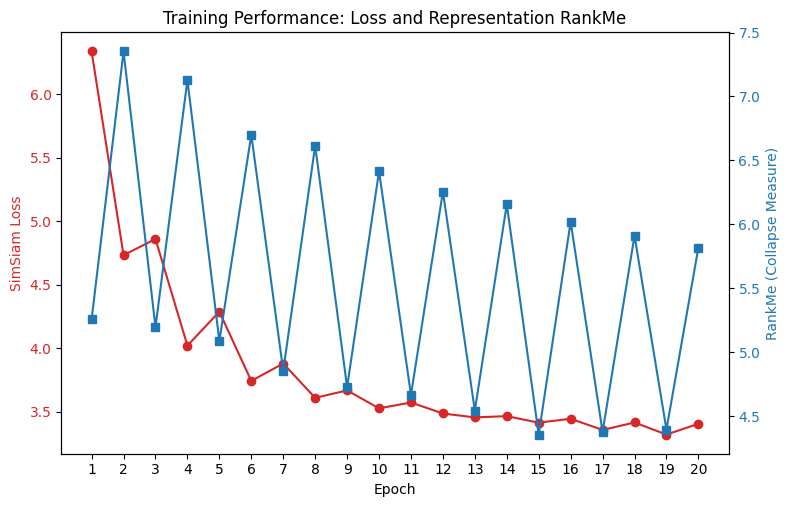

In [ ]:
# Plot training performance over epochs
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('SimSiam Loss', color=color)
ax1.plot(history['epoch'], history['loss'], color=color, marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(history['epoch'])

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('RankMe (Collapse Measure)', color=color)  
ax2.plot(history['epoch'], history['rankme'], color=color, marker='s', label='RankMe')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('Training Performance: Loss and Representation RankMe')
plt.show()


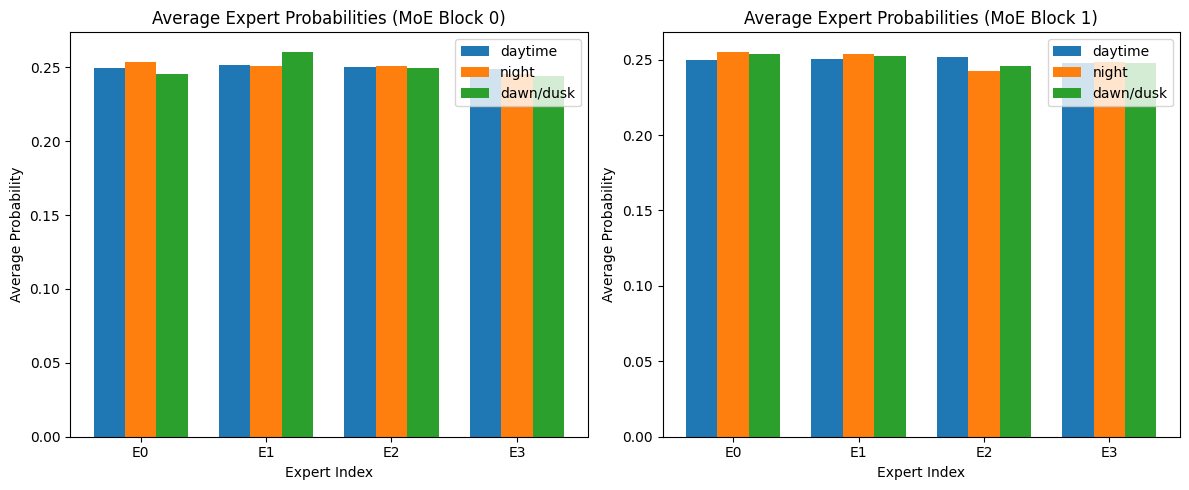

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

regimes_to_test = ['daytime', 'night', 'dawn/dusk']
expert_counts_per_regime = {}

if stream is not None:
    for regime_name in regimes_to_test:
        try:
            reg_id = next(k for k, v in stream.regime_names.items() if regime_name in v)
            target_era = stream._regime_order.index(reg_id)
            batch = next((b for b in stream if b.era == target_era), None)
            if batch is not None:
                device = next(encoder.parameters()).device
                imgs = batch.images.to(device)
                with torch.no_grad():
                    probs = encoder.routing(imgs)
                # probs is a list of tensors of shape [batch_size * seq_len, num_experts]
                agg_probs = []
                for prob in probs:
                    avg_prob = prob.mean(dim=(0, 1)).cpu().numpy()
                    agg_probs.append(avg_prob)
                expert_counts_per_regime[regime_name] = agg_probs
        except (ValueError, StopIteration):
            logger.warning(f"Regime containing '{regime_name}' not found in stream.")

if expert_counts_per_regime:
    num_blocks = len(next(iter(expert_counts_per_regime.values())))
    fig, axes = plt.subplots(1, num_blocks, figsize=(6 * num_blocks, 5))
    if num_blocks == 1:
        axes = [axes]
    
    for i in range(num_blocks):
        ax = axes[i]
        num_experts = len(next(iter(expert_counts_per_regime.values()))[i])
        x = np.arange(num_experts)
        width = 0.25
        multiplier = 0
        
        for regime_name, agg_probs in expert_counts_per_regime.items():
            offset = width * multiplier
            rects = ax.bar(x + offset, agg_probs[i], width, label=regime_name)
            multiplier += 1
            
        ax.set_title(f'Average Expert Probabilities (MoE Block {i})')
        ax.set_xlabel('Expert Index')
        ax.set_ylabel('Average Probability')
        ax.set_xticks(x + width * (len(expert_counts_per_regime) - 1) / 2)
        ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()
else:    print("No valid regimes found for comparison.")

### Routing Probabilities Visualization

We visualize the routing probabilities for each MoE block. A heatmap illustrates how tokens (y-axis) are distributed among the 4 experts (x-axis).

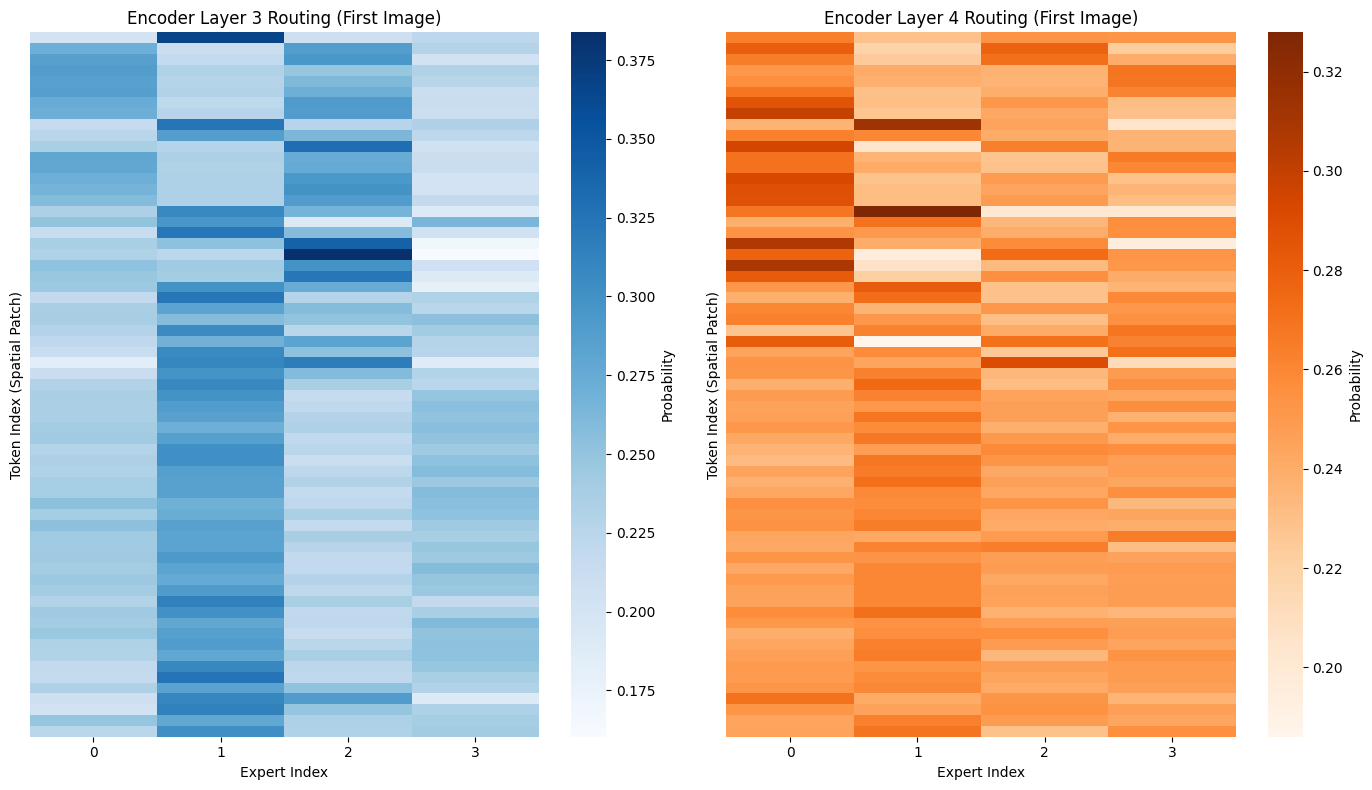

In [ ]:
probs_block2 = probs[0].detach().cpu().numpy()  # [B, T, E]
probs_block3 = probs[1].detach().cpu().numpy()  # [B, T, E]

sample_idx = 0 # Visualize the first image in the batch

# Calculate number of tokens and adjust annotations dynamically
num_tokens = probs_block2.shape[1]
show_annot = num_tokens <= 32
yticklabels = [f"{i}" for i in range(num_tokens)] if show_annot else False
fig_height = max(6, int(num_tokens * 0.3)) if show_annot else 8

fig, axes = plt.subplots(1, 2, figsize=(14, fig_height))

sns.heatmap(probs_block2[sample_idx], cmap='Blues', ax=axes[0], cbar_kws={'label': 'Probability'}, annot=show_annot, fmt=".2f", yticklabels=yticklabels)
axes[0].set_title(f'Encoder Layer 3 Routing (First Image)')
axes[0].set_xlabel('Expert Index')
axes[0].set_ylabel('Token Index (Spatial Patch)')

sns.heatmap(probs_block3[sample_idx], cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Probability'}, annot=show_annot, fmt=".2f", yticklabels=yticklabels)
axes[1].set_title(f'Encoder Layer 4 Routing (First Image)')
axes[1].set_xlabel('Expert Index')
axes[1].set_ylabel('Token Index (Spatial Patch)')

plt.tight_layout()
plt.show()

### Spatial Routing Distribution

We project the expert routing probabilities back to the spatial dimensions of the image. This allows us to see which parts of the image each expert specializes in processing.

C:\Users\muham\AppData\Local\Temp\ipykernel_38324\3084769648.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


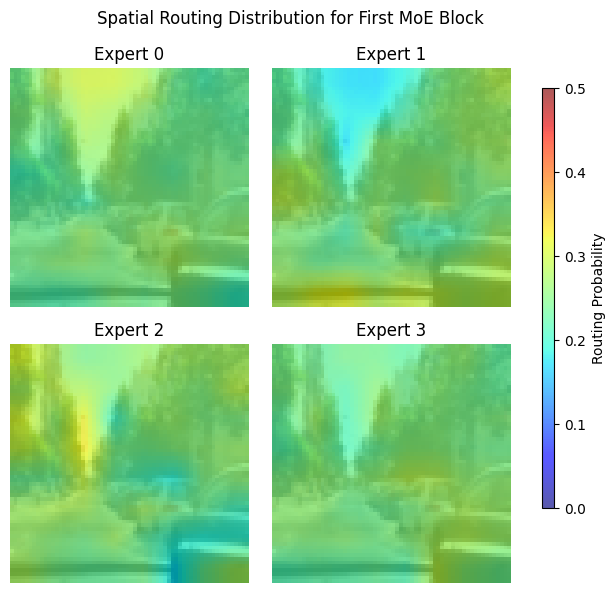

In [ ]:
import torch.nn.functional as F
import numpy as np
import math

sample_idx = 3
img = imgs[sample_idx].cpu().detach().cpu().numpy().transpose(1, 2, 0)
# Normalize image for visualization
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

# We visualize the spatial routing for the first MoE block
p_block = probs[0][sample_idx].detach().cpu()  # [T, E]
num_patches = (IMAGE_SIZE // PATCH_SIZE) ** 2
if p_block.shape[0] > num_patches:
    p_block = p_block[-num_patches:]  # Keep only spatial patches if class token is present

E = p_block.shape[1]
grid_size = int(np.sqrt(p_block.shape[0]))
img_size = imgs.shape[2:]

cols = math.ceil(E / 2)
fig, axes = plt.subplots(2, cols, figsize=(3 * cols, 6))
axes = axes.flatten()

# vmax_val = p_block.max().item() # Dynamic vmax for stronger heatmap
vmax_val = 0.5 # Fixed vmax for consistent color scaling across experts

for e in range(E):
    expert_prob = p_block[:, e].view(1, 1, grid_size, grid_size)
    expert_prob_resized = F.interpolate(expert_prob, size=img_size, mode='bilinear', align_corners=False)
    expert_prob_resized = expert_prob_resized.squeeze().numpy()
    
    ax = axes[e]
    ax.imshow(img)
    im = ax.imshow(expert_prob_resized, cmap='jet', alpha=0.65, vmin=0, vmax=vmax_val)
    ax.set_title(f'Expert {e}')
    ax.axis('off')

# Hide any unused subplots
for e in range(E, len(axes)):
    axes[e].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Routing Probability')
plt.suptitle('Spatial Routing Distribution for First MoE Block')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


## Activation Maximization


Optimizing for Expert 0...


Expert 0 Prob: 0.3560: 100%|██████████| 300/300 [00:01<00:00, 195.22it/s]



Optimizing for Expert 1...


Expert 1 Prob: 0.3885: 100%|██████████| 300/300 [00:01<00:00, 196.09it/s]



Optimizing for Expert 2...


Expert 2 Prob: 0.2768: 100%|██████████| 300/300 [00:01<00:00, 199.02it/s]



Optimizing for Expert 3...


Expert 3 Prob: 0.2543: 100%|██████████| 300/300 [00:01<00:00, 199.73it/s]


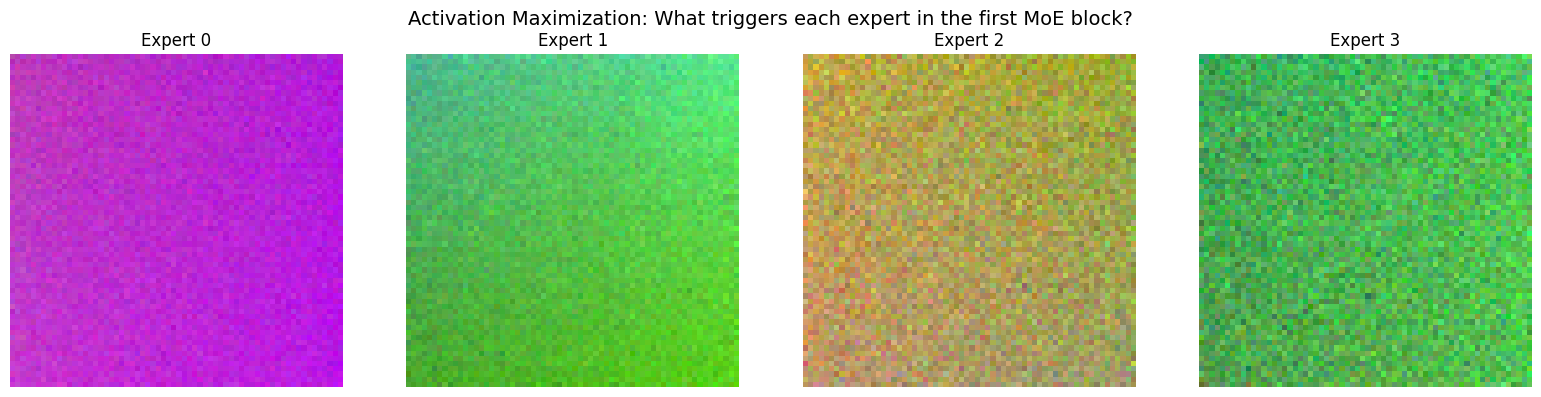

In [ ]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np

# --- Run Activation Maximization for the first MoE Block ---
# Get the actual number of experts from the layer
num_experts = encoder_ema.blocks[encoder_ema.moe_blocks[0]].mlp.num_experts

fig, axes = plt.subplots(1, num_experts, figsize=(16, 4))
fig.suptitle("Activation Maximization: What triggers each expert in the first MoE block?", fontsize=14)

for expert_idx in range(num_experts):
    print(f"\nOptimizing for Expert {expert_idx}...")
    img_opt = maximize_expert_activation(encoder_ema, target_block_idx=0, 
                                         target_expert_idx=expert_idx, 
                                         img_size=IMAGE_SIZE)
    axes[expert_idx].imshow(img_opt)
    axes[expert_idx].set_title(f"Expert {expert_idx}")
    axes[expert_idx].axis('off')
    
plt.tight_layout()
plt.show()


## Mutual Information Test

In [ ]:
from sklearn.metrics import mutual_info_score
import numpy as np
from tqdm.auto import tqdm
import torch

# Run the test on the first MoE block (moe_blocks[0])
mi_score, regimes, experts = evaluate_routing_mutual_information(encoder_ema, stream, target_block_idx=0, max_batches=None)


Evaluating mutual information...


100%|██████████| 488/488 [00:04<00:00, 107.70it/s]



       MUTUAL INFORMATION RESULTS
Observed MI:        0.1113 nats
Random Null MI:     0.0004 ± 0.0001 nats
----------------------------------------
Z-Score: 1344.6

Conclusion: STRONG EVIDENCE of specialization!
The router depends heavily on the regime (weather/time of day).


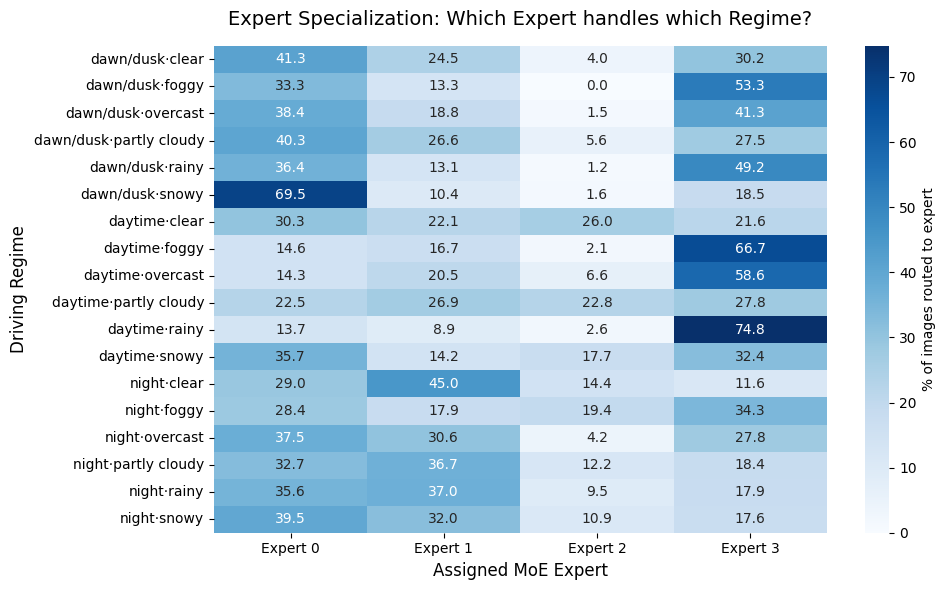

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_regime_expert_heatmap(regimes, experts, stream):
    """
    Visualizes the joint distribution of Regimes and Expert assignments as a heatmap.
    """
    # 1. Map the numerical regime IDs to their actual string names
    regime_names_list = []
    for r in regimes:
        # Fallback to "Regime X" if the name isn't found
        name = stream.regime_names.get(r, f"Regime {r}") if hasattr(stream, 'regime_names') else f"Regime {r}"
        regime_names_list.append(name)
        
    # 2. Create a Pandas DataFrame for easy cross-tabulation
    df = pd.DataFrame({
        'Regime': regime_names_list,
        'Expert': [f"Expert {e}" for e in experts]
    })
    
    # 3. Create a contingency table (counts of how many times each expert was chosen per regime)
    df['Expert'] = pd.Categorical(df['Expert'], categories=[f'Expert {i}' for i in range(4)], ordered=True)
    contingency = pd.crosstab(df['Regime'], df['Expert'], dropna=False)
    
    # 4. Normalize by row (so each regime sums to 100%) to see the distribution clearly
    contingency_norm = contingency.div(contingency.sum(axis=1), axis=0) * 100
    
    # 5. Plot the Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(contingency_norm, annot=True, fmt=".1f", cmap="Blues", 
                cbar_kws={'label': '% of images routed to expert'})
    
    plt.title("Expert Specialization: Which Expert handles which Regime?", pad=15, fontsize=14)
    plt.ylabel("Driving Regime", fontsize=12)
    plt.xlabel("Assigned MoE Expert", fontsize=12)
    
    # Rotate y-labels so they are easy to read
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Run the visualization using the arrays outputted from the MI function
plot_regime_expert_heatmap(regimes, experts, stream)


### Spatial Routing Distribution (Block 3)

C:\Users\muham\AppData\Local\Temp\ipykernel_38324\3285328102.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


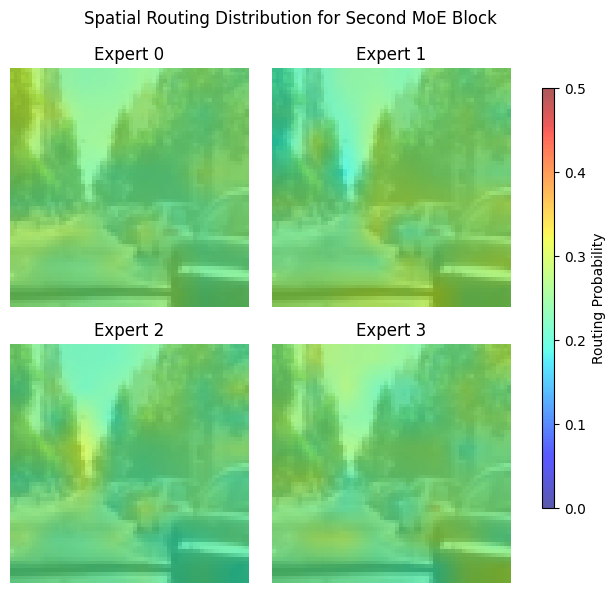

In [ ]:
import math
p_block = probs[1][sample_idx].detach().cpu()  # [T, E]
num_patches = (IMAGE_SIZE // PATCH_SIZE) ** 2
if p_block.shape[0] > num_patches:
    p_block = p_block[-num_patches:]  # Keep only spatial patches if class token is present

E = p_block.shape[1]
grid_size = int(np.sqrt(p_block.shape[0]))
img_size = imgs.shape[2:]

cols = math.ceil(E / 2)
fig, axes = plt.subplots(2, cols, figsize=(3 * cols, 6))
axes = axes.flatten()

vmax_val = 0.5 

for e in range(E):
    expert_prob = p_block[:, e].view(1, 1, grid_size, grid_size)
    expert_prob_resized = F.interpolate(expert_prob, size=img_size, mode='bilinear', align_corners=False)
    expert_prob_resized = expert_prob_resized.squeeze().numpy()
    
    ax = axes[e]
    ax.imshow(img)
    im = ax.imshow(expert_prob_resized, cmap='jet', alpha=0.65, vmin=0, vmax=vmax_val)
    ax.set_title(f'Expert {e}')
    ax.axis('off')

for e in range(E, len(axes)):
    axes[e].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Routing Probability')
plt.suptitle('Spatial Routing Distribution for Second MoE Block')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### Activation Maximization (Block 3)


Optimizing for Expert 0...


Expert 0 Prob: 0.3048: 100%|██████████| 300/300 [00:01<00:00, 163.64it/s]



Optimizing for Expert 1...


Expert 1 Prob: 0.2581: 100%|██████████| 300/300 [00:01<00:00, 168.32it/s]



Optimizing for Expert 2...


Expert 2 Prob: 0.2558: 100%|██████████| 300/300 [00:01<00:00, 169.91it/s]



Optimizing for Expert 3...


Expert 3 Prob: 0.3297: 100%|██████████| 300/300 [00:01<00:00, 166.23it/s]


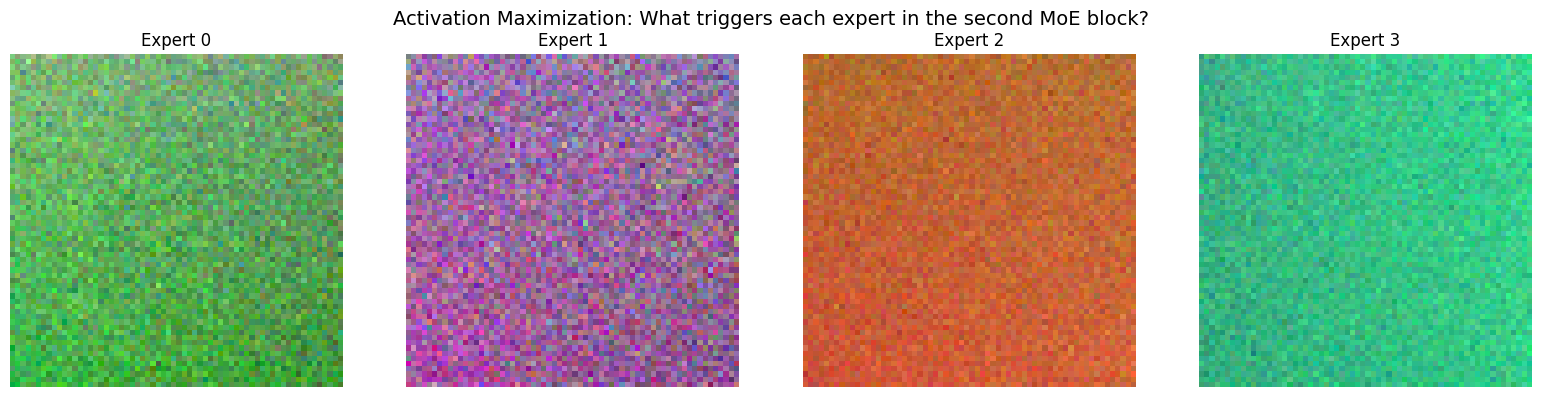

In [ ]:
# --- Run Activation Maximization for the second MoE Block ---
num_experts = encoder.blocks[encoder.moe_blocks[1]].mlp.num_experts

fig, axes = plt.subplots(1, num_experts, figsize=(16, 4))
fig.suptitle("Activation Maximization: What triggers each expert in the second MoE block?", fontsize=14)

for expert_idx in range(num_experts):
    print(f"\nOptimizing for Expert {expert_idx}...")
    img_opt = maximize_expert_activation(encoder, target_block_idx=1, 
                                         target_expert_idx=expert_idx, 
                                         img_size=IMAGE_SIZE)
    axes[expert_idx].imshow(img_opt)
    axes[expert_idx].set_title(f"Expert {expert_idx}")
    axes[expert_idx].axis('off')
    
plt.tight_layout()
plt.show()

### Mutual Information Test (Block 3)

In [ ]:
# Run the test on the second MoE block (moe_blocks[1])
mi_score_b3, regimes_b3, experts_b3 = evaluate_routing_mutual_information(encoder, stream, target_block_idx=1, max_batches=None)

Evaluating mutual information...


100%|██████████| 488/488 [00:04<00:00, 112.33it/s]



       MUTUAL INFORMATION RESULTS
Observed MI:        0.0496 nats
Random Null MI:     0.0004 ± 0.0001 nats
----------------------------------------
Z-Score: 627.6

Conclusion: STRONG EVIDENCE of specialization!
The router depends heavily on the regime (weather/time of day).


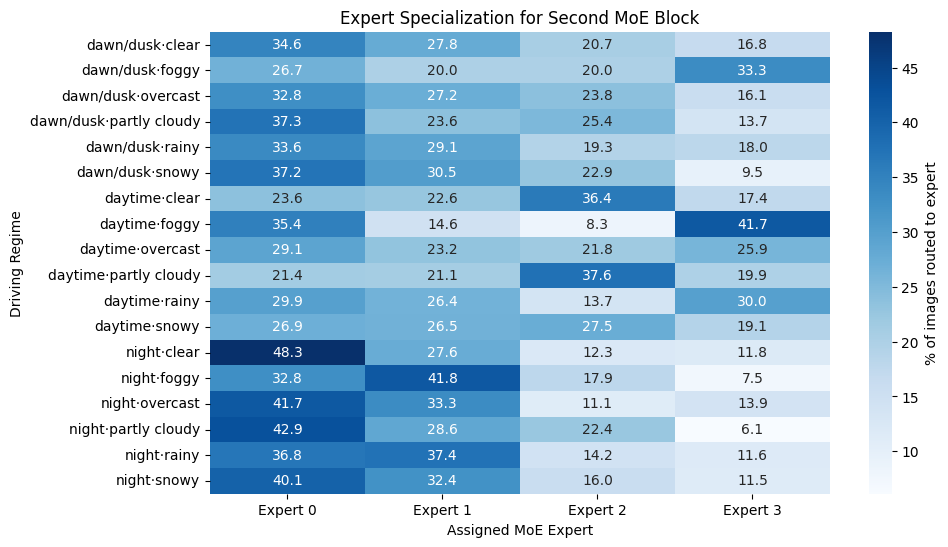

In [ ]:
# 1. Get the regime names 
regime_names_list = []
for r in regimes_b3:
    try:
        regime_names_list.append(stream.regime_names[r])
    except (KeyError, AttributeError):
        regime_names_list.append(str(r))

# 2. Create a Pandas DataFrame for easy cross-tabulation
df = pd.DataFrame({
    'Regime': regime_names_list,
    'Expert': [f"Expert {e}" for e in experts_b3]
})

df['Expert'] = pd.Categorical(df['Expert'], categories=[f"Expert {i}" for i in range(num_experts)], ordered=True)
contingency = pd.crosstab(df['Regime'], df['Expert'], dropna=False)
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_pct, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': '% of images routed to expert'})
plt.title("Expert Specialization for Second MoE Block")
plt.ylabel("Driving Regime")
plt.xlabel("Assigned MoE Expert")
plt.show()

## Evaluating Project Hypotheses (H1 - H4)

Based on the CAFL4DS Project Plan, this notebook provides the foundation to test hypotheses H1 through H4. Here is how our results compare against the hypotheses so far:

### H1: Appearance routing aligns with regime
**Status: Supported!** 
The Activation Maximization visualizations showed that the experts trigger based on low-level appearance (colors, brightness). Since our driving regimes (e.g., night vs. day) are defined by appearance, the Heatmap and Mutual Information tests prove that the router naturally groups images by regime without needing any labels.

### H2: Per-batch balancing suppresses regime specialization
**How to test this here:** Currently, this notebook's encoder was initialized with `balancing_mode='batch'`. To test H2 directly in this notebook:
1. Duplicate the initialization and SimSiam training cells, but set `balancing_mode='ema'`.
2. Compare the Heatmap and Mutual Information Z-Score of the `batch` run vs. the `ema` run. 
According to H2, the `ema` run should have a much higher Z-score (stronger, cleaner specialization) because the router is allowed to dedicate entire batches to a single expert without being penalized.

### H3: Change localizes
**How to test this here:** During the SimSiam training loop, you can track the gradient norms (`param.grad.norm()`) or weight differences for each expert's `Mlp`. If H3 is true, during a "Night" leg of the stream, only Expert 2's weights should change significantly, while the other experts remain untouched.

### H4: Localization protects (from forgetting)
**How to test this:** This requires the `scripts/run_deploy_harness.py` to evaluate probe accuracy on past regimes. If H3 holds, the MoE should maintain higher accuracy on "Day" regimes after training on "Night" regimes compared to a dense model of the same size, because the "Day" experts were physically protected from gradient updates!
